<a href="https://colab.research.google.com/github/AamnahFaiyaz/Capstone-Projects/blob/main/Iris_Flower_Classification/Aamnah_Faiyaz_Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


# Dataset URL from GitHub
dataset_url = "https://raw.githubusercontent.com/AamnahFaiyaz/CodeSoft/main/Iris%20Flower%20Classification/IRIS.csv"

# Load the dataset
iris_df = pd.read_csv(dataset_url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# Display the first 5 rows
print("\nFirst 5 rows of the dataset:")
display(iris_df.head())

# Get information about the dataset (data types, non-null values)
print("\nDataset Information:")
iris_df.info()

# Get descriptive statistics of the numerical columns
print("\nDescriptive Statistics:")
display(iris_df.describe())

# Check the distribution of the target variable (species)
print("\nSpecies Distribution:")
display(iris_df['species'].value_counts())


First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Descriptive Statistics:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Species Distribution:


,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
# Check for missing values
print("\nMissing values per column:")
display(iris_df.isnull().sum())

# If there were missing values, we would handle them here. For this dataset, it appears clean.


Missing values per column:


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


Generating Pairplot...


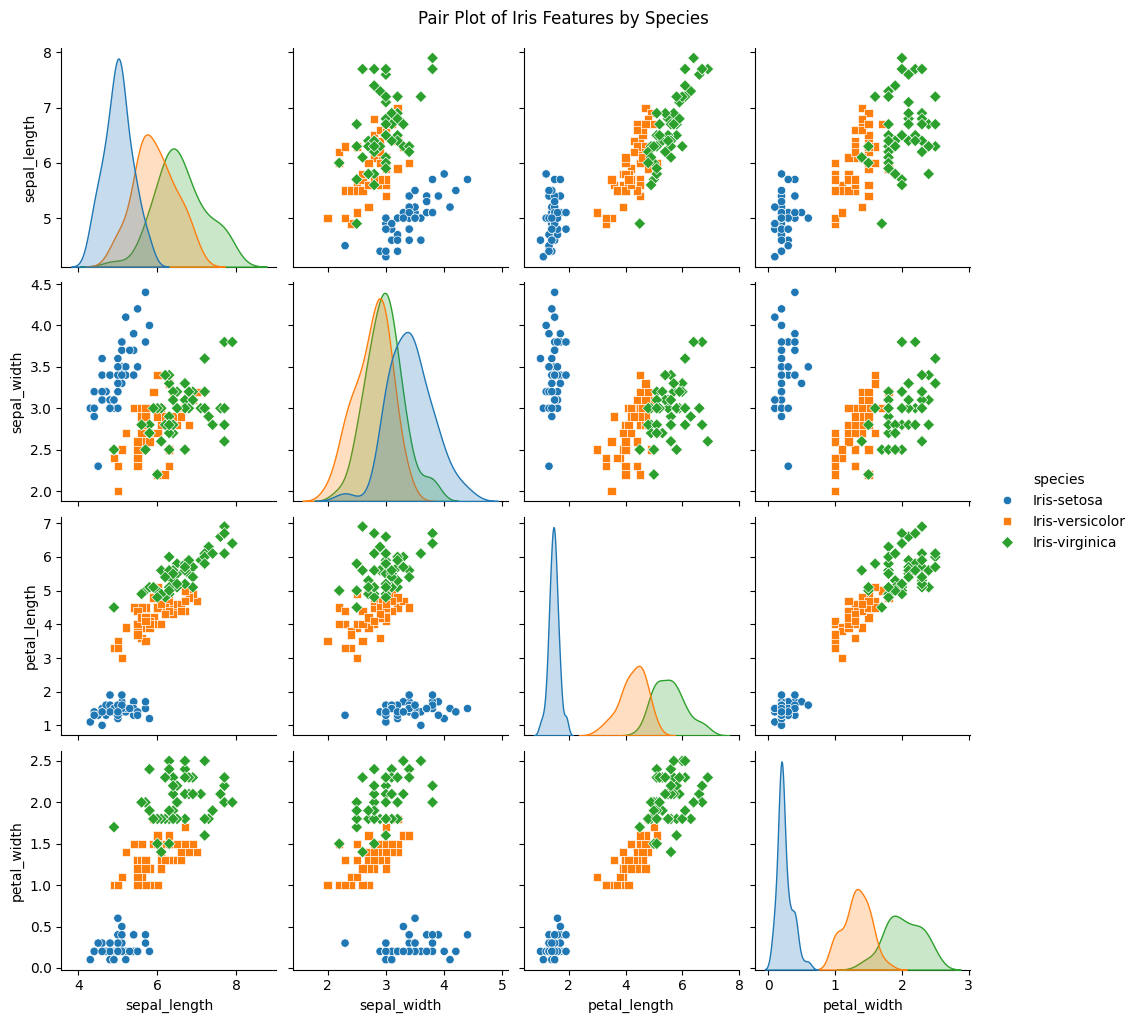

Pairplot generated.


In [ ]:
# Pairplot to visualize relationships between features colored by species
print("Generating Pairplot...")
sns.pairplot(iris_df, hue='species', markers=['o', 's', 'D'])
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02)
plt.show()
print("Pairplot generated.")

Generating Correlation Heatmap...


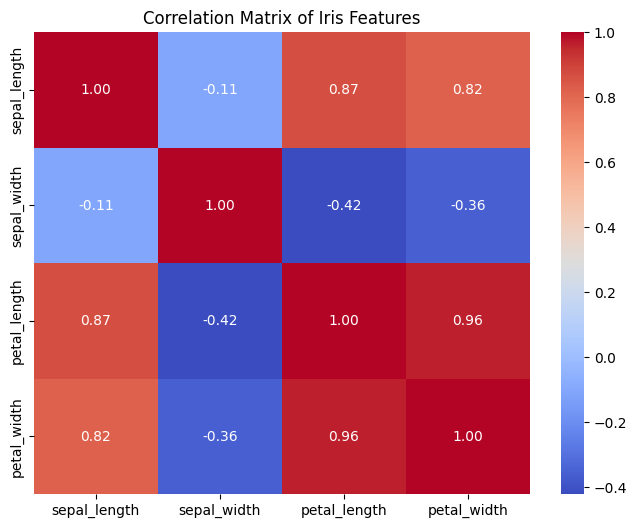

Correlation Heatmap generated.


In [ ]:
# Heatmap to visualize the correlation matrix of numerical features
print("Generating Correlation Heatmap...")
plt.figure(figsize=(8, 6))
sns.heatmap(iris_df.drop('species', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Iris Features')
plt.show()
print("Correlation Heatmap generated.")

In [ ]:
# Separate features (X) and target (y)
X = iris_df.drop('species', axis=1)
y = iris_df['species']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Original dataset shape: {X.shape}, {y.shape}")
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Original dataset shape: (150, 4), (150,)
Training set shape: (120, 4), (120,)
Testing set shape: (30, 4), (30,)


In [ ]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("Predictions on the test set made successfully!")

Predictions on the test set made successfully!


In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1 Score: 0.9666

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30




Confusion Matrix:


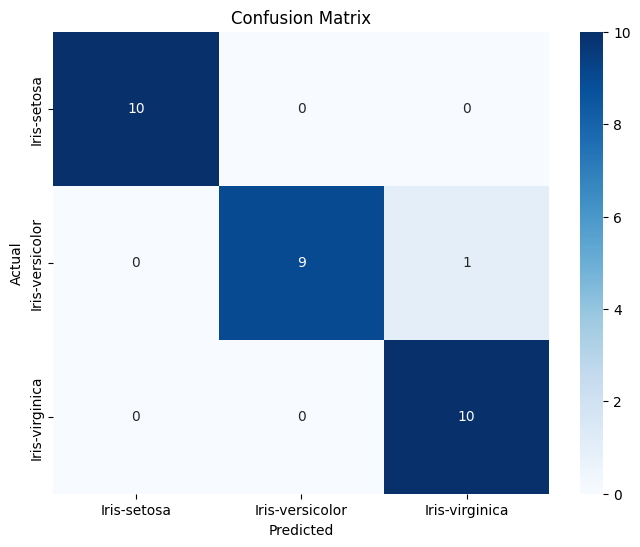

In [ ]:
# Create and display Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()